In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score


In [3]:
url = r"C:\Users\CL506_19\Downloads\insurance_claims.csv"
df = pd.read_csv(url);
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [5]:
if "_c39" in df.columns:
    df.drop(columns=["_c39"], inplace=True)

In [6]:
#Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,532,2,1,1000,1406.91,0,466132,...,2,2,71610,6510,13020,52080,10,1,2004,1
1,228,42,342868,821,1,1,2000,1197.22,5000000,468176,...,0,0,5070,780,780,3510,8,12,2007,1
2,134,29,687698,186,2,0,2000,1413.14,5000000,430632,...,3,1,34650,7700,3850,23100,4,30,2007,0
3,256,41,227811,766,0,1,2000,1415.74,6000000,608117,...,2,1,63400,6340,6340,50720,3,34,2014,1
4,228,44,367455,181,0,2,1000,1583.91,6000000,610706,...,1,1,6500,1300,650,4550,0,31,2009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,487,2,2,1000,1310.80,0,431289,...,1,0,87200,17440,8720,61040,6,6,2006,0
996,285,41,186934,129,0,0,1000,1436.79,0,608177,...,3,0,108480,18080,18080,72320,13,28,2015,0
997,130,34,918516,509,2,1,500,1383.49,3000000,442797,...,3,2,67500,7500,7500,52500,11,19,1996,0
998,458,62,533940,573,0,2,2000,1356.92,5000000,441714,...,1,2,46980,5220,5220,36540,1,5,1998,0


In [9]:
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

fraud_reported
0    753
1    247
Name: count, dtype: int64


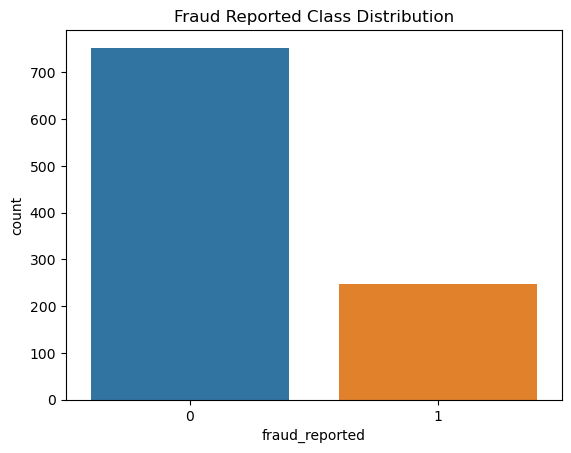

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class distribution
print(df['fraud_reported'].value_counts())

# Visualize class distribution
sns.countplot(x='fraud_reported', data=df)  # Corrected parameter 'data=df'
plt.title('Fraud Reported Class Distribution')  # More descriptive title
plt.show()


In [16]:
from imblearn.over_sampling import SMOTE

# If you're using SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_train, y_train)

# After applying SMOTE, check the new distribution of the classes:
print(pd.Series(y_res).value_counts())


fraud_reported
0    608
1    608
Name: count, dtype: int64


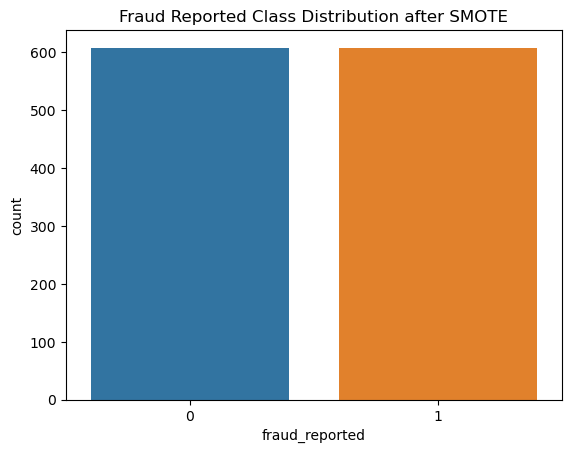

In [18]:
# Visualize the class distribution in the resampled data
sns.countplot(x=y_res)  # Corrected to directly pass y_res, as it's a Series now
plt.title('Fraud Reported Class Distribution after SMOTE')  # More descriptive title
plt.show()


In [19]:
# My Notes :-
# hyperparameters :- MaxDepth, n_estimators, max_leaf_nodes, max_no_features, 
# n_estimators - Number of Trees -> More the trees more the overfitting
param_grid = { 'n_estimators' : [50,100,200],
                'max_depth' : [5,10,20],
                'min_samples_split' : [2,5,10],
                'min_samples_leaf' : [1,2,4]
             }



In [20]:
rf_classifier = RandomForestClassifier(random_state=42)

# using Grid Search 
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)


In [21]:
# Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

# Get the best parameters found by GridSearchCV
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [22]:
# Get the best model
best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train,y_train)

# Predict on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Set: {accuracy:.2f}")

# You can also get more detailed metrics
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy on Test Set: 0.77
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       145
           1       0.61      0.40      0.48        55

    accuracy                           0.77       200
   macro avg       0.70      0.65      0.67       200
weighted avg       0.75      0.77      0.75       200

[[131  14]
 [ 33  22]]


In [23]:
#final model Parallel -> Boosting -> Sequnctialy
#bagging
#Boosting


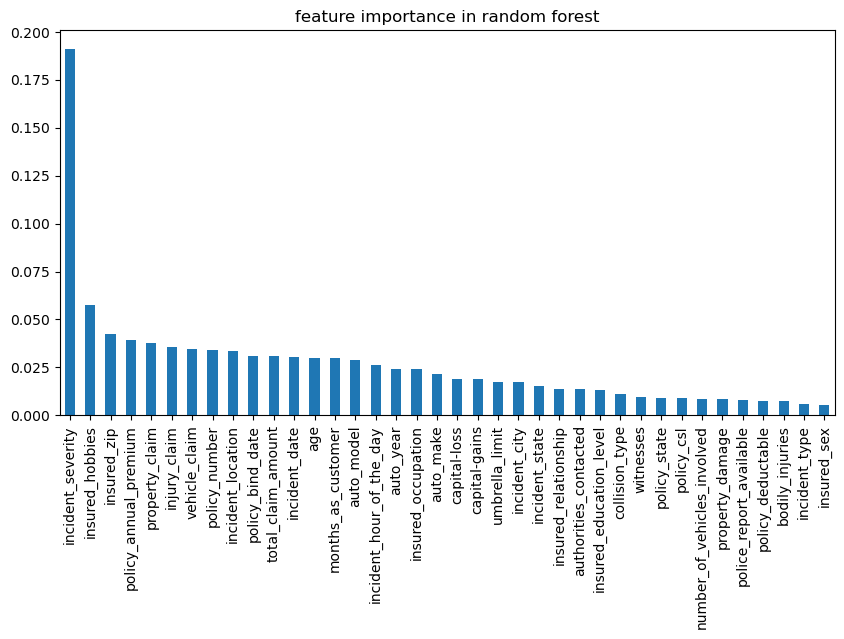

In [25]:
# Feature importance visualization
feature_importances = pd.Series(best_rf_model.feature_importances_,index=df.drop(columns=['fraud_reported']).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title="feature importance in random forest")
plt.show()

In [26]:
# -----------------------------------------------Adaboost------------------------------------------------
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(n_estimators=100,learning_rate=0.5,random_state=42)
adaboost.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=0.5, n_estimators=100, random_state=42)

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

# Define the model with hyperparameters
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Fit the model on the training data
gb.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=5, random_state=42)

In [28]:
# ----------------------- Evaluation---------------------------------
models = {
    "Random Forest" : best_rf_model,
    "AdaBoost" : adaboost,
    "Gradient Boosting" : gb
}

for name,model in models.items():
    print(f"\n{name} Performance")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"Accuracy : {accuracy:.4f}")
    print("Classification Report: \n", classification_report(y_test,y_pred))
    print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))


Random Forest Performance
Accuracy : 0.7650
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       145
           1       0.61      0.40      0.48        55

    accuracy                           0.77       200
   macro avg       0.70      0.65      0.67       200
weighted avg       0.75      0.77      0.75       200

Confusion Matrix :
 [[131  14]
 [ 33  22]]

AdaBoost Performance
Accuracy : 0.7450
Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       145
           1       0.56      0.35      0.43        55

    accuracy                           0.74       200
   macro avg       0.67      0.62      0.63       200
weighted avg       0.72      0.74      0.72       200

Confusion Matrix :
 [[130  15]
 [ 36  19]]

Gradient Boosting Performance
Accuracy : 0.7850
Classification Report: 
               precision    recall  f1-score   suppo